In [4]:
# prompt: 請讀取Churn_Modelling.csv，並顯示其前五行

import pandas as pd

# Assuming Churn_Modelling.csv is in the current working directory.

df = pd.read_csv('Churn_Modelling.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42.0,2,0.00,1,1.0,1.0,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41.0,1,83807.86,1,0.0,1.0,112542.58,0
2,3,15619304,Onio,502,France,Female,42.0,8,159660.80,3,1.0,0.0,113931.57,1
3,4,15701354,Boni,699,France,Female,39.0,1,0.00,2,0.0,0.0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43.0,2,125510.82,1,NaN,1.0,79084.10,0


In [5]:
# prompt: 使用 DataFrame df: 請將資料中的RowNumber、CustomerId、Surname之欄位數據進行移除 （資料預處理）

# Remove the specified columns from the DataFrame
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42.0,2,0.00,1,1.0,1.0,101348.88,1
1,608,Spain,Female,41.0,1,83807.86,1,0.0,1.0,112542.58,0
2,502,France,Female,42.0,8,159660.80,3,1.0,0.0,113931.57,1
3,699,France,Female,39.0,1,0.00,2,0.0,0.0,93826.63,0
4,850,Spain,Female,43.0,2,125510.82,1,NaN,1.0,79084.10,0


In [6]:
# prompt: 請對資料判斷是否有缺失值

# Check for missing values in each column
missing_values = df.isnull().sum()

# Print the number of missing values for each column
print(missing_values)

# Check if there are any missing values in the entire DataFrame
if df.isnull().values.any():
    print("\nThere are missing values in the DataFrame.")
else:
    print("\nThere are no missing values in the DataFrame.")

CreditScore        0
Geography          1
Gender             0
Age                1
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          1
IsActiveMember     1
EstimatedSalary    0
Exited             0
dtype: int64

There are missing values in the DataFrame.


In [7]:
# prompt: 接下來請對 Geography利用眾數補值，Age用中位數來補值，而 HasCrCard、IsActiveMember 則是用衆數來補值 （資料預處理）

import pandas as pd

# Assuming Churn_Modelling.csv is in the current working directory.
df = pd.read_csv('Churn_Modelling.csv')
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# Fill missing values
# Geography: Mode Imputation
df['Geography'] = df['Geography'].fillna(df['Geography'].mode()[0])

# Age: Median Imputation
df['Age'] = df['Age'].fillna(df['Age'].median())

# HasCrCard: Mode Imputation
df['HasCrCard'] = df['HasCrCard'].fillna(df['HasCrCard'].mode()[0])

# IsActiveMember: Mode Imputation
df['IsActiveMember'] = df['IsActiveMember'].fillna(df['IsActiveMember'].mode()[0])


# Verify if missing values are filled
missing_values_after = df.isnull().sum()
print(missing_values_after)

if df.isnull().values.any():
    print("\nThere are still missing values in the DataFrame.")
else:
    print("\nThere are no missing values in the DataFrame.")


CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

There are no missing values in the DataFrame.


In [8]:
# prompt: 請將資料中的 Gender 的欄位進行Label Encoding，而 Geography 的欄位則是進行 One-hot Enocoding，以做到類別特徵之轉換（數據類型轉換）

import pandas as pd
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# Assuming Churn_Modelling.csv is in the current working directory.
df = pd.read_csv('Churn_Modelling.csv')
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# Fill missing values (same as before)
# Geography: Mode Imputation
df['Geography'] = df['Geography'].fillna(df['Geography'].mode()[0])

# Age: Median Imputation
df['Age'] = df['Age'].fillna(df['Age'].median())

# HasCrCard: Mode Imputation
df['HasCrCard'] = df['HasCrCard'].fillna(df['HasCrCard'].mode()[0])

# IsActiveMember: Mode Imputation
df['IsActiveMember'] = df['IsActiveMember'].fillna(df['IsActiveMember'].mode()[0])


# Label Encoding for 'Gender'
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

# One-Hot Encoding for 'Geography'
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False) # sparse=False for dense array
geography_encoded = ohe.fit_transform(df[['Geography']])

# Create new columns for one-hot encoded features
geography_encoded_df = pd.DataFrame(geography_encoded, columns=ohe.get_feature_names_out(['Geography']))

# Concatenate the encoded features with the original dataframe
df = pd.concat([df, geography_encoded_df], axis=1)
df = df.drop('Geography', axis=1)

# Display the first few rows of the transformed DataFrame
df.head()


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,619,0,42.0,2,0.00,1,1.0,1.0,101348.88,1,1.0,0.0,0.0
1,608,0,41.0,1,83807.86,1,0.0,1.0,112542.58,0,0.0,0.0,1.0
2,502,0,42.0,8,159660.80,3,1.0,0.0,113931.57,1,1.0,0.0,0.0
3,699,0,39.0,1,0.00,2,0.0,0.0,93826.63,0,1.0,0.0,0.0
4,850,0,43.0,2,125510.82,1,1.0,1.0,79084.10,0,0.0,0.0,1.0


In [9]:
# prompt: # prompt: 請針對以上資料進行SVM模型建模，特徵變數：CreditScore	Gender	Age	Tenure	Balance	NumOfProducts	HasCrCard	IsActiveMember	EstimatedSalary Geography_France	Geography_Germany	Geography_Spain
# # ，目標變數：Exited，顯示該模型之參數並進行初始化（先不用進行訓練，但先設定目標變數和特徵變數）

from sklearn.svm import SVC

# Define features (X) and target (y)
X = df[['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_France', 'Geography_Germany', 'Geography_Spain']]
y = df['Exited']

# Initialize the SVM model with default parameters
svm_model = SVC()

# Display model parameters
print(svm_model.get_params())


{'C': 1.0, 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'scale', 'kernel': 'rbf', 'max_iter': -1, 'probability': False, 'random_state': None, 'shrinking': True, 'tol': 0.001, 'verbose': False}


In [29]:
#請以訓練資料及測試資料比率為9：1，並顯示其各部分資料筆數，並訓練及評估SVM模型(未特定調參)
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

# ... (Previous code remains the same)

# Define features (X) and target (y)
X = df[['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_France', 'Geography_Germany', 'Geography_Spain']]
y = df['Exited']

# Split data into training and testing sets (9:1 ratio)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
# 接著標準化
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Number of training samples:", len(X_train))
print("Number of testing samples:", len(X_test))

# 初始化並訓練 SVM
svm_model = SVC(kernel='rbf', probability=True, random_state=42)

svm_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = svm_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

print(classification_report(y_test, y_pred))

Number of training samples: 9001
Number of testing samples: 1001
Accuracy: 0.8531468531468531
              precision    recall  f1-score   support

           0       0.87      0.97      0.91       803
           1       0.74      0.39      0.51       198

    accuracy                           0.85      1001
   macro avg       0.80      0.68      0.71      1001
weighted avg       0.84      0.85      0.83      1001



In [36]:
#請以訓練資料及測試資料比率為8：2，並顯示其各部分資料筆數，並訓練及評估SVM模型(未特定調參)
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

# ... (Previous code remains the same)

# Define features (X) and target (y)
X = df[['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_France', 'Geography_Germany', 'Geography_Spain']]
y = df['Exited']

# Split data into training and testing sets (8:2 ratio)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)
# 接著標準化
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Number of training samples:", len(X_train))
print("Number of testing samples:", len(X_test))

# 初始化並訓練 SVM
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
# Print the number of samples in each set
svm_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = svm_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

print(classification_report(y_test, y_pred))

Number of training samples: 8001
Number of testing samples: 2001
Accuracy: 0.8595702148925537
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1599
           1       0.79      0.41      0.54       402

    accuracy                           0.86      2001
   macro avg       0.83      0.69      0.73      2001
weighted avg       0.85      0.86      0.84      2001



In [31]:
#請以訓練資料及測試資料比率為7：3，並顯示其各部分資料筆數，並訓練及評估SVM模型(未特定調參)
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

# ... (Previous code remains the same)

# Define features (X) and target (y)
X = df[['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_France', 'Geography_Germany', 'Geography_Spain']]
y = df['Exited']

# Split data into training and testing sets (9:1 ratio)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3 ,random_state=42)
# 接著標準化
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Number of training samples:", len(X_train))
print("Number of testing samples:", len(X_test))

# 初始化並訓練 SVM
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
# Print the number of samples in each set
svm_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = svm_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

print(classification_report(y_test, y_pred))

Number of training samples: 7001
Number of testing samples: 3001
Accuracy: 0.8620459846717761
              precision    recall  f1-score   support

           0       0.87      0.98      0.92      2401
           1       0.80      0.41      0.54       600

    accuracy                           0.86      3001
   macro avg       0.84      0.69      0.73      3001
weighted avg       0.86      0.86      0.84      3001



In [33]:
#請以訓練資料及測試資料比率為6：4，並顯示其各部分資料筆數，並訓練及評估SVM模型(未特定調參)
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

# ... (Previous code remains the same)

# Define features (X) and target (y)
X = df[['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_France', 'Geography_Germany', 'Geography_Spain']]
y = df['Exited']

# Split data into training and testing sets (9:1 ratio)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4 ,random_state=42)
# 接著標準化
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Number of training samples:", len(X_train))
print("Number of testing samples:", len(X_test))

# 初始化並訓練 SVM
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
# Print the number of samples in each set
svm_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = svm_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

print(classification_report(y_test, y_pred))

Number of training samples: 6001
Number of testing samples: 4001
Accuracy: 0.8585353661584604
              precision    recall  f1-score   support

           0       0.86      0.98      0.92      3196
           1       0.81      0.39      0.53       805

    accuracy                           0.86      4001
   macro avg       0.84      0.68      0.72      4001
weighted avg       0.85      0.86      0.84      4001



In [37]:
# prompt: 接下來請以訓練資料及測試資料比率為9：1，並顯示其各部分資料筆數，並訓練及評估SVM模型(有進行調參)

# ... (Previous code remains the same)

# Define features (X) and target (y)
X = df[['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_France', 'Geography_Germany', 'Geography_Spain']]
y = df['Exited']

# Split data into training and testing sets (8:2 ratio)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# Print the number of samples in each set
print("Number of training samples:", len(X_train))
print("Number of testing samples:", len(X_test))

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Initialize and train the SVM model with specified hyperparameters
svm_model = SVC(kernel='rbf', C=1, gamma=0.1, probability=True, random_state=42) # Example hyperparameters
svm_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = svm_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

print(classification_report(y_test, y_pred))



Number of training samples: 9001
Number of testing samples: 1001
Accuracy: 0.8551448551448552
              precision    recall  f1-score   support

           0       0.87      0.97      0.91       803
           1       0.75      0.40      0.52       198

    accuracy                           0.86      1001
   macro avg       0.81      0.69      0.72      1001
weighted avg       0.84      0.86      0.84      1001



In [38]:
# prompt: 接下來請以訓練資料及測試資料比率為8：2，並顯示其各部分資料筆數，並訓練及評估SVM模型(有進行調參)

# ... (Previous code remains the same)

# Define features (X) and target (y)
X = df[['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_France', 'Geography_Germany', 'Geography_Spain']]
y = df['Exited']

# Split data into training and testing sets (8:2 ratio)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print the number of samples in each set
print("Number of training samples:", len(X_train))
print("Number of testing samples:", len(X_test))

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Initialize and train the SVM model with specified hyperparameters
svm_model = SVC(kernel='rbf', C=1, gamma=0.1, probability=True, random_state=42) # Example hyperparameters
svm_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = svm_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

print(classification_report(y_test, y_pred))



Number of training samples: 8001
Number of testing samples: 2001
Accuracy: 0.8600699650174912
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1599
           1       0.79      0.41      0.54       402

    accuracy                           0.86      2001
   macro avg       0.83      0.69      0.73      2001
weighted avg       0.85      0.86      0.84      2001



In [39]:
# prompt: 接下來請以訓練資料及測試資料比率為7：3，並顯示其各部分資料筆數，並訓練及評估SVM模型(有進行調參)

# ... (Previous code remains the same)

# Define features (X) and target (y)
X = df[['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_France', 'Geography_Germany', 'Geography_Spain']]
y = df['Exited']

# Split data into training and testing sets (7:3 ratio)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Print the number of samples in each set
print("Number of training samples:", len(X_train))
print("Number of testing samples:", len(X_test))

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Initialize and train the SVM model with specified hyperparameters
svm_model = SVC(kernel='rbf', C=1, gamma=0.1, probability=True, random_state=42) # Example hyperparameters
svm_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = svm_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

print(classification_report(y_test, y_pred))


Number of training samples: 7001
Number of testing samples: 3001
Accuracy: 0.862379206931023
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      2401
           1       0.80      0.42      0.55       600

    accuracy                           0.86      3001
   macro avg       0.83      0.70      0.73      3001
weighted avg       0.86      0.86      0.84      3001



In [40]:
# prompt: 接下來請以訓練資料及測試資料比率為6：4，並顯示其各部分資料筆數，並訓練及評估SVM模型

# Define features (X) and target (y)
X = df[['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_France', 'Geography_Germany', 'Geography_Spain']]
y = df['Exited']

# Split data into training and testing sets (6:4 ratio)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

# Print the number of samples in each set
print("Number of training samples:", len(X_train))
print("Number of testing samples:", len(X_test))

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Initialize and train the SVM model with specified hyperparameters
svm_model = SVC(kernel='rbf', C=1, gamma=0.1, probability=True, random_state=42) # Example hyperparameters
svm_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = svm_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

print(classification_report(y_test, y_pred))



Number of training samples: 6001
Number of testing samples: 4001
Accuracy: 0.8590352411897025
              precision    recall  f1-score   support

           0       0.86      0.98      0.92      3196
           1       0.81      0.39      0.53       805

    accuracy                           0.86      4001
   macro avg       0.84      0.68      0.72      4001
weighted avg       0.85      0.86      0.84      4001



Confusion Matrix:
[[2341   60]
 [ 354  246]]


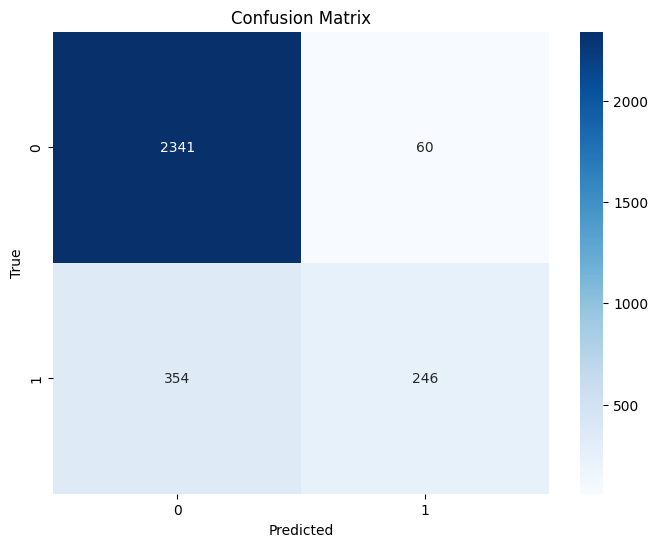


Accuracy: 0.8620459846717761

Precision: 0.803921568627451

Recall: 0.41

F1 Score: 0.543046357615894


In [20]:
# prompt: 接下來請以訓練資料及測試資料比率為7：3來訓練的模型爲基準，來進行預測結果的評估（混淆矩陣、accuracy、precision、recall、f1 score、分隔散佈圖等）（未調參）

import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler

# ... (Previous code remains the same)


# Split data into training and testing sets (7:3 ratio)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Initialize and train the SVM model
svm_model = SVC(kernel='rbf', probability=True, random_state=42) # No specific hyperparameter tuning
svm_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = svm_model.predict(X_test)

# Evaluate the model
print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nPrecision:", precision_score(y_test, y_pred))
print("\nRecall:", recall_score(y_test, y_pred))
print("\nF1 Score:", f1_score(y_test, y_pred))

Confusion Matrix:
[[2337   64]
 [ 349  251]]


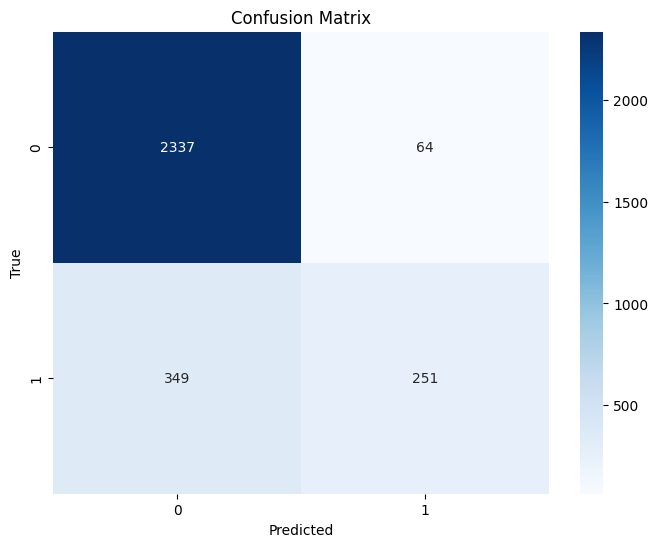


Accuracy: 0.862379206931023

Precision: 0.7968253968253968

Recall: 0.41833333333333333

F1 Score: 0.5486338797814208


In [21]:
# prompt: 接下來請以訓練資料及測試資料比率為7：3來訓練的模型爲基準，其中運用到 C=1, gamma=0.1調參，來進行預測結果的評估（混淆矩陣、accuracy、precision、recall、f1 score、分隔散佈圖等）（調參）

import matplotlib.pyplot as plt
import numpy as np
# ... (Previous code remains the same)

# Split data into training and testing sets (7:3 ratio)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Initialize and train the SVM model with C=1, gamma=0.1
svm_model = SVC(kernel='rbf', C=1, gamma=0.1, probability=True, random_state=42)
svm_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = svm_model.predict(X_test)

# Evaluate the model
print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nPrecision:", precision_score(y_test, y_pred))
print("\nRecall:", recall_score(y_test, y_pred))
print("\nF1 Score:", f1_score(y_test, y_pred))


Missing values in each column:
 CreditScore        0
Geography          1
Gender             0
Age                1
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          1
IsActiveMember     1
EstimatedSalary    0
Exited             0
dtype: int64

There are missing values in the DataFrame.

Missing values after imputation:
 CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

There are no missing values.

Number of training samples: 7001
Number of testing samples: 3001

--- Model Evaluation ---
Confusion Matrix:
 [[2341   60]
 [ 354  246]]


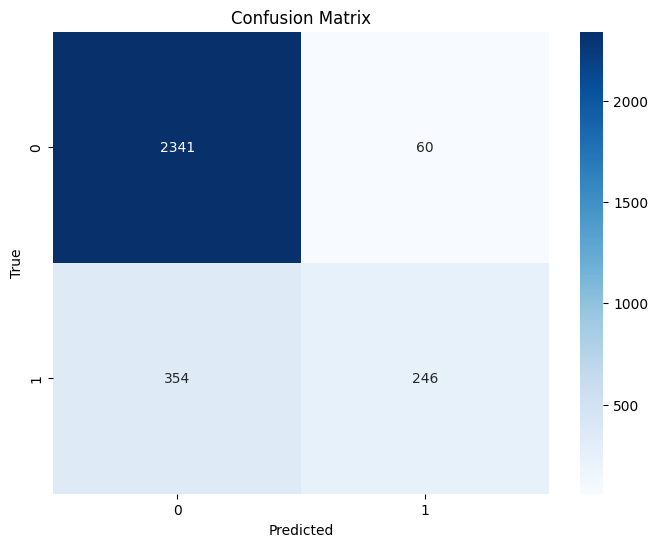

Accuracy: 0.8620459846717761
Precision: 0.803921568627451
Recall: 0.41
F1 Score: 0.543046357615894

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.98      0.92      2401
           1       0.80      0.41      0.54       600

    accuracy                           0.86      3001
   macro avg       0.84      0.69      0.73      3001
weighted avg       0.86      0.86      0.84      3001



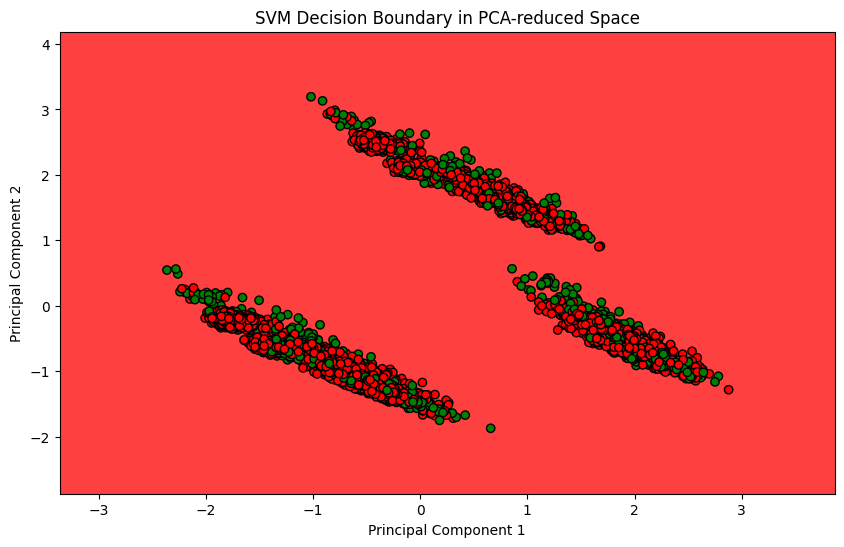

In [24]:
#SVM
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# scikit-learn 相關匯入
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, classification_report,confusion_matrix, precision_score, recall_score, f1_score)
from matplotlib.colors import ListedColormap
from sklearn.decomposition import PCA

### 1. 讀取資料
df = pd.read_csv('Churn_Modelling.csv')

### 2. 資料預處理
# 移除不必要的欄位
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# 檢查缺失值
missing_values = df.isnull().sum()
print("Missing values in each column:\n", missing_values)
if df.isnull().values.any():
    print("\nThere are missing values in the DataFrame.")
else:
    print("\nThere are no missing values in the DataFrame.")

# 補值：Geography 用眾數, Age 用中位數, HasCrCard 與 IsActiveMember 用眾數
df['Geography'] = df['Geography'].fillna(df['Geography'].mode()[0])
df['Age'] = df['Age'].fillna(df['Age'].median())
df['HasCrCard'] = df['HasCrCard'].fillna(df['HasCrCard'].mode()[0])
df['IsActiveMember'] = df['IsActiveMember'].fillna(df['IsActiveMember'].mode()[0])

# 再次檢查缺失值
print("\nMissing values after imputation:\n", df.isnull().sum())
if df.isnull().values.any():
    print("\nThere are still missing values.")
else:
    print("\nThere are no missing values.")

# 類別特徵轉換
# Label Encoding for Gender
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

# One-Hot Encoding for Geography
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
geography_encoded = ohe.fit_transform(df[['Geography']])
geography_encoded_df = pd.DataFrame(geography_encoded,columns=ohe.get_feature_names_out(['Geography']))
# 合併並移除原 Geography 欄位
df = pd.concat([df.drop('Geography', axis=1), geography_encoded_df], axis=1)

### 3. 定義特徵與標籤
features = ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance',
            'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
            'Geography_France', 'Geography_Germany', 'Geography_Spain']
X = df[features]
y = df['Exited']

### 4. 資料分割與標準化 (分割比例 7:3)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print("\nNumber of training samples:", len(X_train))
print("Number of testing samples:", len(X_test))

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 5. SVM 模型建立、訓練與預測 (未特定調參)
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)
y_pred = svm_model.predict(X_test_scaled)

### 6. 評估模型
print("\n--- Model Evaluation ---")
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

### 7. 多特徵決策邊界視覺化：利用 PCA 將 12 維降至 2 維
# 對全部訓練資料進行 PCA 降維，n_components=2
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# 用降維後資料訓練 SVM 模型（可重新設定超參數）
svm_pca = SVC(kernel='rbf', probability=True, random_state=42)
svm_pca.fit(X_train_pca, y_train)

# 產生網格座標以畫決策邊界
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))

Z = svm_pca.predict(np.array([xx.ravel(), yy.ravel()]).T)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.75, cmap=ListedColormap(('red', 'green')))
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, edgecolors='k', cmap=ListedColormap(('red', 'green')))
plt.title('SVM Decision Boundary in PCA-reduced Space')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()


Missing values in each column:
 CreditScore        0
Geography          1
Gender             0
Age                1
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          1
IsActiveMember     1
EstimatedSalary    0
Exited             0
dtype: int64

There are missing values in the DataFrame.

Missing values after imputation:
 CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

There are no missing values.

Number of training samples: 7001
Number of testing samples: 3001

--- Model Evaluation ---
Confusion Matrix:
 [[2337   64]
 [ 349  251]]


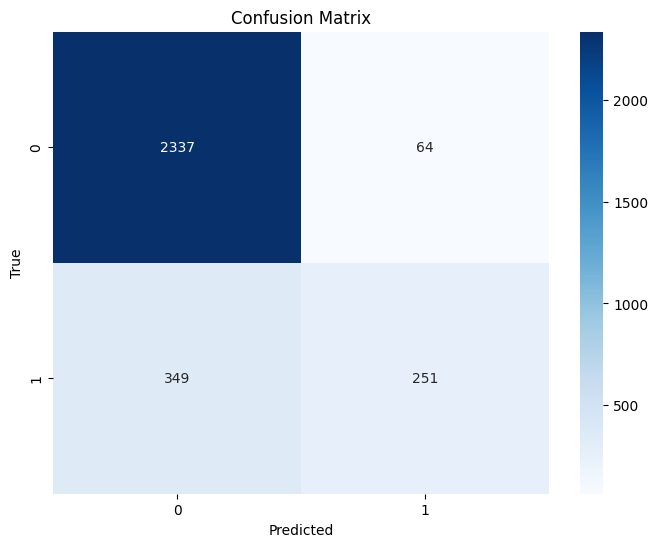

Accuracy: 0.862379206931023
Precision: 0.7968253968253968
Recall: 0.41833333333333333
F1 Score: 0.5486338797814208

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.97      0.92      2401
           1       0.80      0.42      0.55       600

    accuracy                           0.86      3001
   macro avg       0.83      0.70      0.73      3001
weighted avg       0.86      0.86      0.84      3001



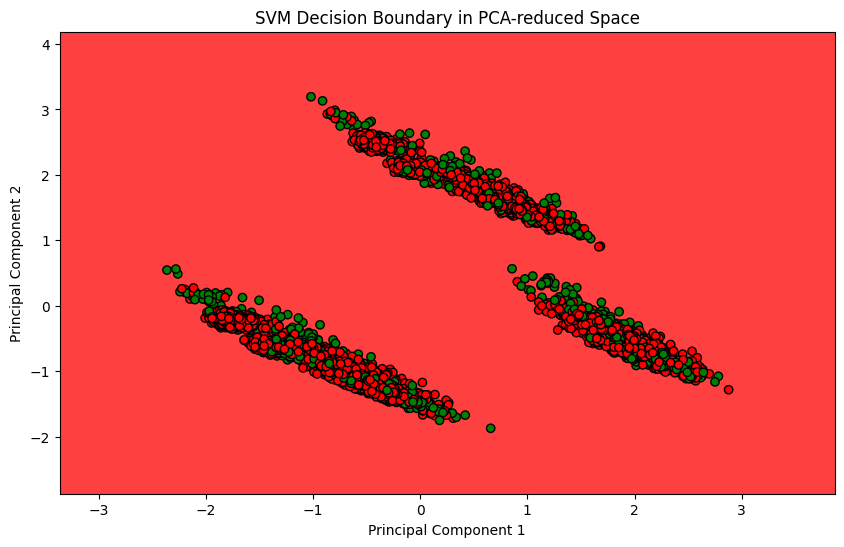

In [26]:
#SVM調參
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# scikit-learn 相關匯入
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, classification_report,confusion_matrix, precision_score, recall_score, f1_score)
from matplotlib.colors import ListedColormap
from sklearn.decomposition import PCA

### 1. 讀取資料
df = pd.read_csv('Churn_Modelling.csv')

### 2. 資料預處理
# 移除不必要的欄位
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# 檢查缺失值
missing_values = df.isnull().sum()
print("Missing values in each column:\n", missing_values)
if df.isnull().values.any():
    print("\nThere are missing values in the DataFrame.")
else:
    print("\nThere are no missing values in the DataFrame.")

# 補值：Geography 用眾數, Age 用中位數, HasCrCard 與 IsActiveMember 用眾數
df['Geography'] = df['Geography'].fillna(df['Geography'].mode()[0])
df['Age'] = df['Age'].fillna(df['Age'].median())
df['HasCrCard'] = df['HasCrCard'].fillna(df['HasCrCard'].mode()[0])
df['IsActiveMember'] = df['IsActiveMember'].fillna(df['IsActiveMember'].mode()[0])

# 再次檢查缺失值
print("\nMissing values after imputation:\n", df.isnull().sum())
if df.isnull().values.any():
    print("\nThere are still missing values.")
else:
    print("\nThere are no missing values.")

# 類別特徵轉換
# Label Encoding for Gender
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

# One-Hot Encoding for Geography
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
geography_encoded = ohe.fit_transform(df[['Geography']])
geography_encoded_df = pd.DataFrame(geography_encoded,columns=ohe.get_feature_names_out(['Geography']))
# 合併並移除原 Geography 欄位
df = pd.concat([df.drop('Geography', axis=1), geography_encoded_df], axis=1)

### 3. 定義特徵與標籤
features = ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance',
            'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
            'Geography_France', 'Geography_Germany', 'Geography_Spain']
X = df[features]
y = df['Exited']

### 4. 資料分割與標準化 (分割比例 7:3)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print("\nNumber of training samples:", len(X_train))
print("Number of testing samples:", len(X_test))

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 5. SVM 模型建立、訓練與預測 (特定調參)
svm_model = SVC(kernel='rbf', C=1, gamma=0.1, probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)
y_pred = svm_model.predict(X_test_scaled)

### 6. 評估模型
print("\n--- Model Evaluation ---")
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

### 7. 多特徵決策邊界視覺化：利用 PCA 將 12 維降至 2 維
# 對全部訓練資料進行 PCA 降維，n_components=2
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# 用降維後資料訓練 SVM 模型（可重新設定超參數）
svm_pca = SVC(kernel='rbf', C=1, gamma=0.1, probability=True, random_state=42)
svm_pca.fit(X_train_pca, y_train)

# 產生網格座標以畫決策邊界
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))

Z = svm_pca.predict(np.array([xx.ravel(), yy.ravel()]).T)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.75, cmap=ListedColormap(('red', 'green')))
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, edgecolors='k', cmap=ListedColormap(('red', 'green')))
plt.title('SVM Decision Boundary in PCA-reduced Space')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()
